In [1]:
print('Running imports...')
import os
import random

import torch # long
import numpy as np
import lightning as L
import xarray as xr
import wandb
import matplotlib

from torch.utils.data import DataLoader, TensorDataset, random_split
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything

import pandas as pd
import cartopy.crs as ccrs

import argparse

from models.lightning import LitCNN_regression, AttributableTrainer, LogPlotsRegression
from models.losses import get_loss
from models.model import Wang2024, CNN_LSTM_Model, CNN_BiLSTM_Attention
from models.data import get_input_data
from models.attributions import log_attribution_regression

Running imports...


In [ ]:
train_loader, valid_loader, test_loader, ds_test = get_input_data(input_variable=['u850','v850','w850'], batch_size=64,
                       LSTM_sequence=True,n_days_predicted = 50)
image_size = ds_test.longitude.size * ds_test.latitude.size











In [ ]:

def get_input_data(input_variable, batch_size=64, 
                   lags_between_predictor_and_predictants = 0,
                   file_name_data_in = '/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_NH_32x128.nc',
                   file_name_data_out = '/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc',
                   LSTM_sequence=True, n_days_predictant = 3,
                   region_predicted=14, n_days_predicted = 10,
                   trainval_test_split_ratio = 0.8,
                   train_val_split_ratio = 0.8,
                   ):
    """
    Daily data required
    """
    with xr.open_dataset(file_name_data_in) as data_in:
        ds_in = data_in.data_normed.load().sel(var_name=input_variable)

    
    if LSTM_sequence:
        all_shifts = []
        for k in range(n_days_predictant):
            ds_shift = ds_in.shift(time=k)
            ds_shift = ds_shift.assign_coords(lag=f"lag{k}" )
            all_shifts.append(ds_shift)
        ds_in = xr.concat(all_shifts[::-1], dim='lag_in_past').transpose('time','lag_in_past','var_name','latitude','longitude')
    ds_in = ds_in.isel(time=slice(n_days_predictant-1, None))

    with xr.open_dataarray(file_name_data_out) as ds_out:
        data_out = ds_out.sel(mask_id=region_predicted)
        all_out_shift = []
        for k in range(n_days_predicted):
            data_out_shift = data_out.shift(time=-k).assign_coords(lag=f"day+{k}")
            all_out_shift.append(data_out_shift)
        ds_out = xr.concat(all_out_shift, dim='lag')
    ds_out = ds_out.isel(time=slice(None, -n_days_predicted+1))

    common_time = ds_in.time.loc[dict(time=ds_in.time.isin(ds_out.time))]
    if len(common_time)==0:
        raise ValueError("No common time between input and ouput datasets")
    ds_in, ds_out = ds_in.sel(time=common_time), ds_out.sel(time=common_time)

    if lags_between_predictor_and_predictants>0:
        ds_in = ds_in.shift(time=lags_between_predictor_and_predictants)
        ds_in = ds_in.isel(time=slice(lags_between_predictor_and_predictants,None))
        ds_out = ds_in.isel(time=slice(lags_between_predictor_and_predictants,None))
        
    sample_size = ds_in.time.size
    sample_size
    trainval_size, test_size = int(sample_size*trainval_test_split_ratio), sample_size - int(sample_size*trainval_test_split_ratio)
    train_size, val_size = int(trainval_size*train_val_split_ratio), trainval_size - int(trainval_size*train_val_split_ratio)
    times_shuffled = np.random.permutation(ds_in.time.values)
    train_times, valid_times, test_times = times_shuffled[:train_size], times_shuffled[train_size:train_size+val_size], times_shuffled[train_size+val_size:]

    train_set = TensorDataset(torch.Tensor(ds_in.sel(time=train_times).values).type(torch.float32), 
                            torch.Tensor(ds_out.sel(time=train_times).values).type(torch.float32).T)
    valid_set = TensorDataset(torch.Tensor(ds_in.sel(time=valid_times).values).type(torch.float32), 
                            torch.Tensor(ds_out.sel(time=valid_times).values).type(torch.float32).T)
    test_set = TensorDataset(torch.Tensor(ds_in.sel(time=test_times).values).type(torch.float32), 
                            torch.Tensor(ds_out.sel(time=test_times).values).type(torch.float32).T)

    train_loader = DataLoader(train_set, batch_size=batch_size)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    ds_test = xr.Dataset(dict(data_in=ds_in.sel(time=test_times),
                            data_out = ds_out.sel(time=test_times)))

    return train_loader, valid_loader, test_loader, ds_test

    tensor_in = tensor_in[n_days_predictant:-n_days_predicted]
    tensor_out = tensor_out[n_days_predictant:-n_days_predicted]
    if lags_between_predictor_and_predictants!=0:
        tensor_in = tensor_in[:-lags_between_predictor_and_predictants]
        tensor_out = tensor_out[lags_between_predictor_and_predictants:]
    dataset = TensorDataset(tensor_in, tensor_out)

    # use 20% of data for test
    trainvalid_set_size = int(len(dataset) * 0.8)
    test_set_size = len(dataset) - trainvalid_set_size
    # split the train set into two
    seed = torch.Generator().manual_seed(42)
    trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

    # use 20% of training data for validation
    train_set_size = int(len(trainvalid_set) * 0.8)
    valid_set_size = len(trainvalid_set) - train_set_size

    # split the train set into two
    seed = torch.Generator().manual_seed(43)
    train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)
    # if augment_train_set:
    #     train_set = AugmentedRainfallDataset(train_set, threshold=30.0, noise_std=0.01, augment_factor=1)

    train_loader = DataLoader(train_set, batch_size=batch_size)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    ds_test = ds_shift.shift(time=lags).isel(time=test_loader.dataset.indices)

    return train_loader, valid_loader, test_loader, ds_test
    pass

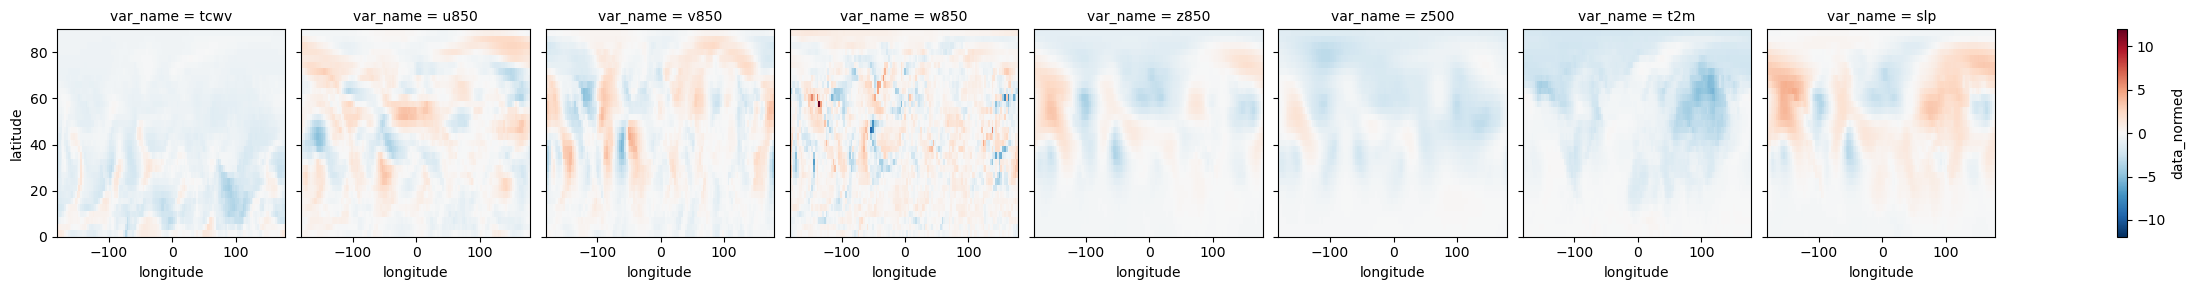

In [12]:
ds = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64_v2.nc')
ds.isel(time=0).data_normed.plot(col='var_name')

In [2]:

def get_input_data_small_extended_multidays_LSTM(
        input_variable, region_predicted, type_prediction, batch_size,
        augment_train_set = False, n_days_predictant=1, n_days_predicted=1,
        include_gradients=True,
        lags=0):
    ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64_v3.nc').data_normed.load().sel(var_name=input_variable)
    all_shifts = []
    for k in range(n_days_predictant):
        ds_shift = ds_in.shift(time=k)
        ds_shift = ds_shift.assign_coords(lag=f"lag{k}" )
        all_shifts.append(ds_shift)
    ds_shift = xr.concat(all_shifts[::-1], dim='lag')
    # if include_gradients:
    #     gradients = ds_shift.diff('lag').assign_coords(lag=[f"Grad{k+1}-{k}" for k in range(n_days_predictant-1)][::-1])
    #     ds_shift_grad = xr.concat([ds_shift, gradients], dim='lag')
    # else:
    #     ds_shift_grad = ds_shift
    ds_shift = ds_shift.transpose('time','lag','var_name','latitude','longitude')
    values_features = ds_shift.values
    tensor_in = torch.Tensor(values_features).type(torch.float32)

    with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20, var_name=0)) as ds_out:
        data_out = ds_out.sel(mask_id=region_predicted)
        if type_prediction=='quantiles':
            data_out = (data_out.rank('time', pct=True)//.1).astype(int)
        all_out_shift = []
        for k in range(n_days_predicted):
            data_out_shift = data_out.shift(time=-k).assign_coords(lag=f"day+{k}")
            all_out_shift.append(data_out_shift)
        data_out_shifts = xr.concat(all_out_shift, dim='lag')
        data_out_values = data_out_shifts.values
    tensor_out = torch.Tensor(data_out_values).type(torch.float32).T

    tensor_in = tensor_in[n_days_predictant:-n_days_predicted]
    tensor_out = tensor_out[n_days_predictant:-n_days_predicted]
    if lags!=0:
        tensor_in = tensor_in[:-lags]
        tensor_out = tensor_out[lags:]
    dataset = TensorDataset(tensor_in, tensor_out)

    # use 20% of data for test
    trainvalid_set_size = int(len(dataset) * 0.8)
    test_set_size = len(dataset) - trainvalid_set_size
    # split the train set into two
    seed = torch.Generator().manual_seed(42)
    trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

    # use 20% of training data for validation
    train_set_size = int(len(trainvalid_set) * 0.8)
    valid_set_size = len(trainvalid_set) - train_set_size

    # split the train set into two
    seed = torch.Generator().manual_seed(43)
    train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)
    # if augment_train_set:
    #     train_set = AugmentedRainfallDataset(train_set, threshold=30.0, noise_std=0.01, augment_factor=1)

    train_loader = DataLoader(train_set, batch_size=batch_size)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    ds_test = ds_shift.shift(time=lags).isel(time=test_loader.dataset.indices)

    return train_loader, valid_loader, test_loader, ds_test

In [3]:
attribute_test = False
wandb_logger = WandbLogger(project="Predict-rain-WNorway_multidays", 
                            save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                            dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

# wandb_logger.experiment # Initialize wandb

# train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended(input_variable=wandb_logger.experiment.config['input_variable'], 
#                                                                                 region_predicted=14,
#                                                                                 type_prediction='regression', 
#                                                                                 batch_size=wandb_logger.experiment.config['batch_size'], 
#                                                                                 lags=wandb_logger.experiment.config['lags'], 
#                                                                                 augment_train_set=False)
train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended_multidays_LSTM(
                    input_variable=wandb_logger.experiment.config['input_variable'], 
                    region_predicted=14,
                    type_prediction='regression', 
                    batch_size=wandb_logger.experiment.config['batch_size'], 
                    lags=wandb_logger.experiment.config['lags'], 
                    augment_train_set=False,
                    n_days_predictant=wandb_logger.experiment.config['num_days_predictant'], 
                    n_days_predicted=wandb_logger.experiment.config['num_days_predicted'],
                    include_gradients=wandb_logger.experiment.config['include_gradient_features'],)

image_size = train_loader.dataset.dataset.dataset.tensors[0].shape[-1]*train_loader.dataset.dataset.dataset.tensors[0].shape[-2]

print('Data ready')

callbacks=[]

trainer = AttributableTrainer(limit_train_batches=100, max_epochs=wandb_logger.experiment.config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="gpu", devices=1,
                            gradient_clip_val=wandb_logger.experiment.config['gradient_clip_val'])

num_classes = wandb_logger.experiment.config['num_days_predicted']
num_output_neurons = num_classes


wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready


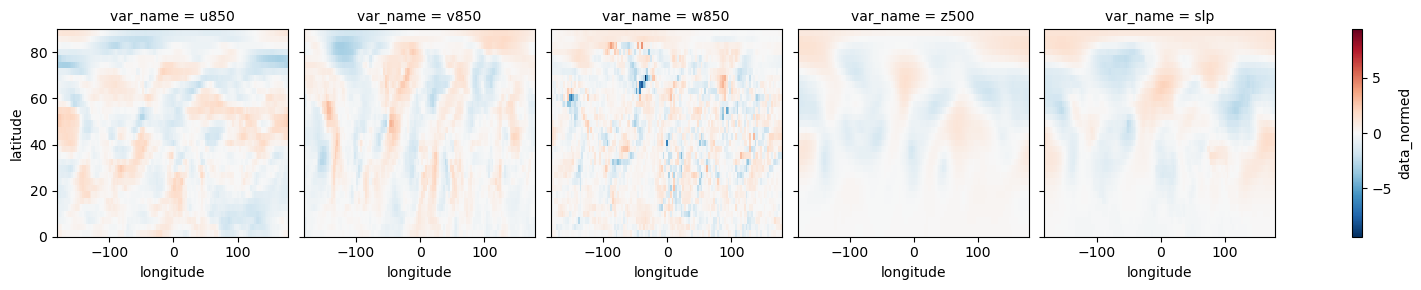

In [4]:
ds_test.isel(time=0).isel(lag=0).plot(col='var_name')

In [5]:
from einops import rearrange
from torch import nn

class VisionTransformerRegressor(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, num_channels_in, dim=128, depth=6, heads=8, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = num_channels_in * patch_size ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, C, H, W = x.shape
        x = rearrange(x, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=H // (H // 16), p2=W // (W // 16))
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :x.shape[1], :]
        x = self.dropout(x)
        x = self.transformer(x)
        x = x[:, 0]
        x = self.mlp_head(x)
        return nn.functional.softplus(x)
    
import timm

class ConvNeXtRegressor(nn.Module):
    def __init__(self, num_classes=1, image_size=224, num_channels=3):
        super().__init__()
        self.image_size = image_size
        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=False,
            features_only=False,
            in_chans=num_channels  # Ensure correct input channels
        )
        self.backbone.head.fc = nn.Linear(self.backbone.num_features, num_classes)
        self.activation = nn.Softplus()

    def forward(self, x):
        print(x.shape)
        assert x.shape[-2:] == (self.image_size, self.image_size), \
            f"Expected input size {(self.image_size, self.image_size)}, but got {x.shape[-2:]}"
        x = self.backbone(x)
        return self.activation(x)

In [11]:
class Attention(nn.Module):
    """Self-Attention Mechanism to focus on important timesteps."""
    def __init__(self, input_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(input_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, hidden_dim)
        attn_weights = torch.softmax(self.attn(x), dim=1)  # (batch, seq_len, 1)
        attended_output = torch.sum(attn_weights * x, dim=1)  # Weighted sum over timesteps
        return attended_output, attn_weights

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_channels=3, num_lstm_units=128, num_fc_units=64,  num_output=1, image_size=64*32):
        super(CNN_BiLSTM_Attention, self).__init__()

        # CNN for spatial feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Compute CNN output size (Assuming 64x64 input images)
        self.cnn_output_dim = 64 * (64 // 4) * (64 // 4)  # Adjust based on input size

        # BiLSTM for temporal learning
        self.bilstm = nn.LSTM(
            input_size=self.cnn_output_dim,
            hidden_size=num_lstm_units,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        # Attention mechanism
        self.attention = Attention(input_dim=num_lstm_units * 2)  # BiLSTM is bidirectional

        # Fully connected layer for regression
        self.fc = nn.Linear(num_lstm_units * 2, num_fc_units)
        self.output_layer = nn.Linear(num_fc_units, num_output)  # Output: Rainfall amount

        self.criterion = nn.MSELoss()

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.shape  # (batch, seq_len, channels, height, width)
        cnn_features = []
        for t in range(seq_len):
            out = self.cnn(x[:, t, :, :, :])  # (batch, 64, H/4, W/4)
            out = out.view(batch_size, -1)  # Flatten
            cnn_features.append(out)

        cnn_features = torch.stack(cnn_features, dim=1)  # (batch, seq_len, feature_dim)

        # BiLSTM processing
        lstm_out, _ = self.bilstm(cnn_features)  # (batch, seq_len, 2 * hidden_size)

        # Apply Attention
        attended_out, attn_weights = self.attention(lstm_out)  # (batch, hidden_dim)

        # Fully connected layers
        x = self.fc(attended_out)
        x = self.output_layer(x)  # (batch, 1)

        return x

In [ ]:
from torch import nn
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, hidden_size, output_size):
        super(CNN_LSTM_Model, self).__init__()
        
        # CNN layers to extract spatial features
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # LSTM layer to capture temporal dependencies
        self.lstm = nn.LSTM(input_size=128*8*8*2, hidden_size=hidden_size, batch_first=True)
        
        # Fully connected layer for final prediction
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size, seq_length, channels, height, width = x.size()
        cnn_out = []
        for i in range(seq_length):
            cnn_out.append(self.cnn(x[:, i, :, :, :]))  # Extract features from each time step
        cnn_out = torch.stack(cnn_out, dim=1)  # Shape: (batch_size, seq_length, channels, height, width)
        # Flatten CNN output for LSTM
        cnn_out = cnn_out.view(batch_size, seq_length, -1)  # Shape: (batch_size, seq_length, features)
        # Apply LSTM
        lstm_out, _ = self.lstm(cnn_out)
        
        # Get last time step output and pass through fully connected layer
        lstm_out = lstm_out[:, -1, :]  # Shape: (batch_size, hidden_size)
        output = self.fc(lstm_out)  # Shape: (batch_size, output_size)
        return output

In [5]:
CNN = CNN_LSTM_Model(input_channels=len(wandb_logger.experiment.config['input_variable']),
                 hidden_size=256,
                 output_size = wandb_logger.experiment.config['num_days_predicted'],
                            image_size = ds_test.longitude.size * ds_test.latitude.size)
CNN = CNN_BiLSTM_Attention(input_channels=len(wandb_logger.experiment.config['input_variable']),
                            num_fc_units=256,
                            num_output = wandb_logger.experiment.config['num_days_predicted'],
                            image_size = ds_test.longitude.size * ds_test.latitude.size)
CNN(train_loader.dataset.dataset.dataset.tensors[0][:10])

tensor([[0.0570, 0.0319, 0.0083],
        [0.0734, 0.0320, 0.0203],
        [0.0963, 0.0434, 0.0314],
        [0.0932, 0.0481, 0.0445],
        [0.0656, 0.0538, 0.0451],
        [0.0584, 0.0557, 0.0489],
        [0.0650, 0.0440, 0.0480],
        [0.0697, 0.0448, 0.0327],
        [0.0755, 0.0402, 0.0287],
        [0.0638, 0.0338, 0.0314]], grad_fn=<AddmmBackward0>)

In [13]:
# CNN = CNN_LSTM_Model(input_channels=len(wandb_logger.experiment.config['input_variable']),
#                  hidden_size=256,
#                  output_size = wandb_logger.experiment.config['num_days_predicted']
#                  )
CNN = CNN_BiLSTM_Attention(input_channels=len(wandb_logger.experiment.config['input_variable']),
                            num_fc_units=256,
                            num_output = wandb_logger.experiment.config['num_days_predicted']
                            )



loss = get_loss(wandb_logger.experiment.config['loss_fn'])


model = LitCNN_regression(CNN, 
                        learning_rate=wandb_logger.experiment.config['learning_rate'], 
                        loss_fn = loss)

print('Model init')
trainer.fit(model, train_loader, valid_loader)

model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=test_loader)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type                 | Params | Mode 
---------------------------------------------------------
0 | model   | CNN_BiLSTM_Attention | 17.4 M | train
1 | loss_fn | MSELoss              | 0      | train
---------------------------------------------------------
17.4 M    Trainable params
0         Non-trainable params
17.4 M    Total params
69.570    Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Model init


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           18.182188034057617
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [14]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.77099237 0.6728281  0.48861284]
Correlations: [0.93040771 0.85889446 0.68375703]


In [22]:
ds_test.isel(time=true_indices).dims

('time', 'lag', 'var_name', 'latitude', 'longitude')

In [23]:
attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.isel(time=true_indices).coords})

In [39]:
((truth>20) &(pred>20)).sum(axis=1)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
min_rain = 20
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()

true_indices = np.where(((truth>20) &(pred>20)).sum(axis=1)>0)[0]
data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
data_out_true_target = torch.Tensor(pred[true_indices])
dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
attribution_loader = DataLoader(dataset_attr, batch_size=10)
# attribution_loader = test_loader
baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(trainer.model.model)
# dl = DeepLift(trainer.model.model)
all_attr = []
for target_day in range(wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.isel(time=true_indices).coords})
    pred_da = xr.DataArray(pred[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test.isel(time=true_indices)-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')
# ds_attr.attrs['baseline_prediction'] = trainer.model(baseline).detach().numpy().squeeze()

Computing Attributions: 100%|██████████| 42/42 [02:52<00:00,  4.10s/it]


In [50]:
def make_gl(ax):
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=1, color='gray', alpha=0.5, linestyle=':')
    gl.xlabels_top = False
    gl.xlabels_bottom = False
    gl.ylabels_left = False
    gl.ylabels_right = False
    # gl.xlines = False
    gl.xlocator = plt.FixedLocator(np.arange(-120,60,30))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8, 'color': 'gray'}
    
    gl.ylabel_style = {'size': 8, 'color': 'gray'}

In [141]:
corr = xr.cov(ds.truth, ds.pred, dim='target_day')
rmse = np.sqrt(((ds.truth - ds.pred)**2).mean('target_day'))
rmse.to_series().reset_index().sort_values(0)

,time,0
383,2015-12-19,0.793348
166,2005-01-10,0.797556
65,2007-05-20,0.900479
329,1991-09-07,0.924533
109,2020-01-18,0.957229
...,...,...
91,2019-09-10,20.808224
158,2005-11-09,22.647930
127,1984-08-25,22.951654
294,2014-10-24,24.366085


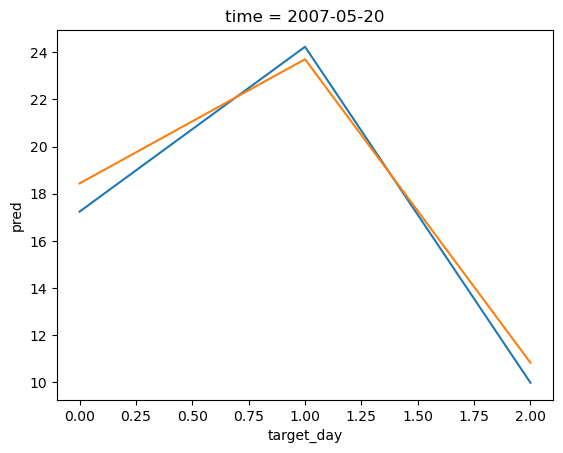

In [144]:
ds.isel(time=65).truth.plot()
ds.isel(time=65).pred.plot()

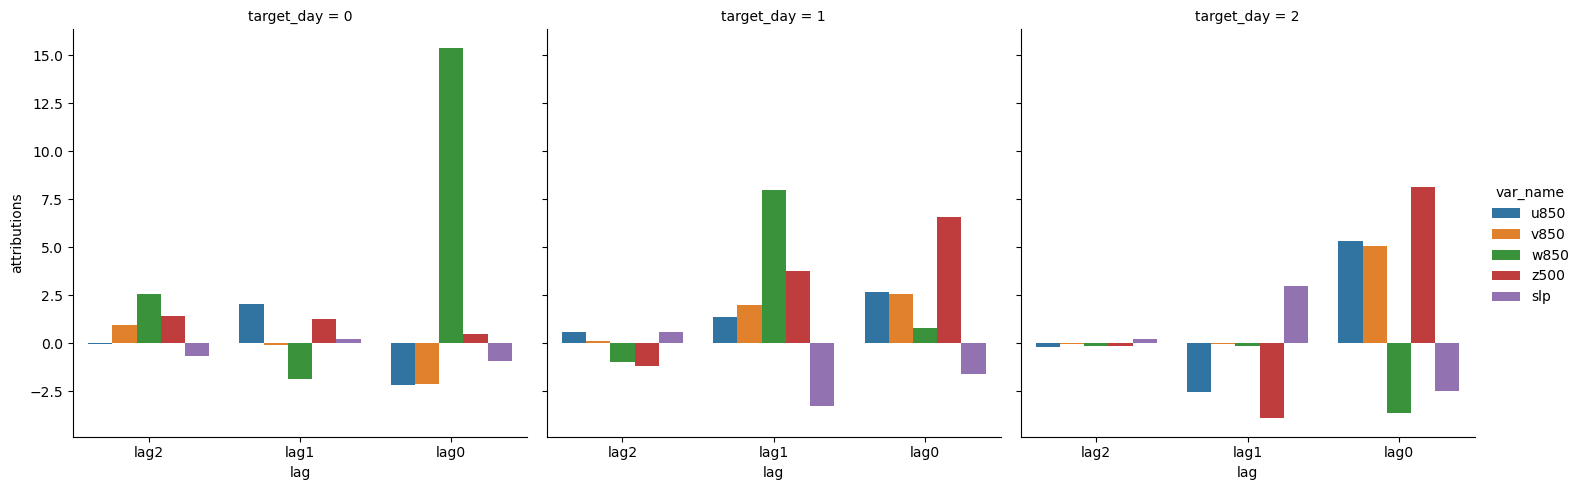

In [145]:
# ds.sel(target_day=2).plot.scatter(x='pred', y='truth')
# ds.isel(time=213).truth.plot()
# ds.isel(time=213).pred.plot()
df_ = ds.isel(time=65).attributions.sum(['longitude','latitude']).to_series().reset_index()
sns.catplot(df_, kind='bar', x='lag', hue='var_name', y='attributions', col='target_day')

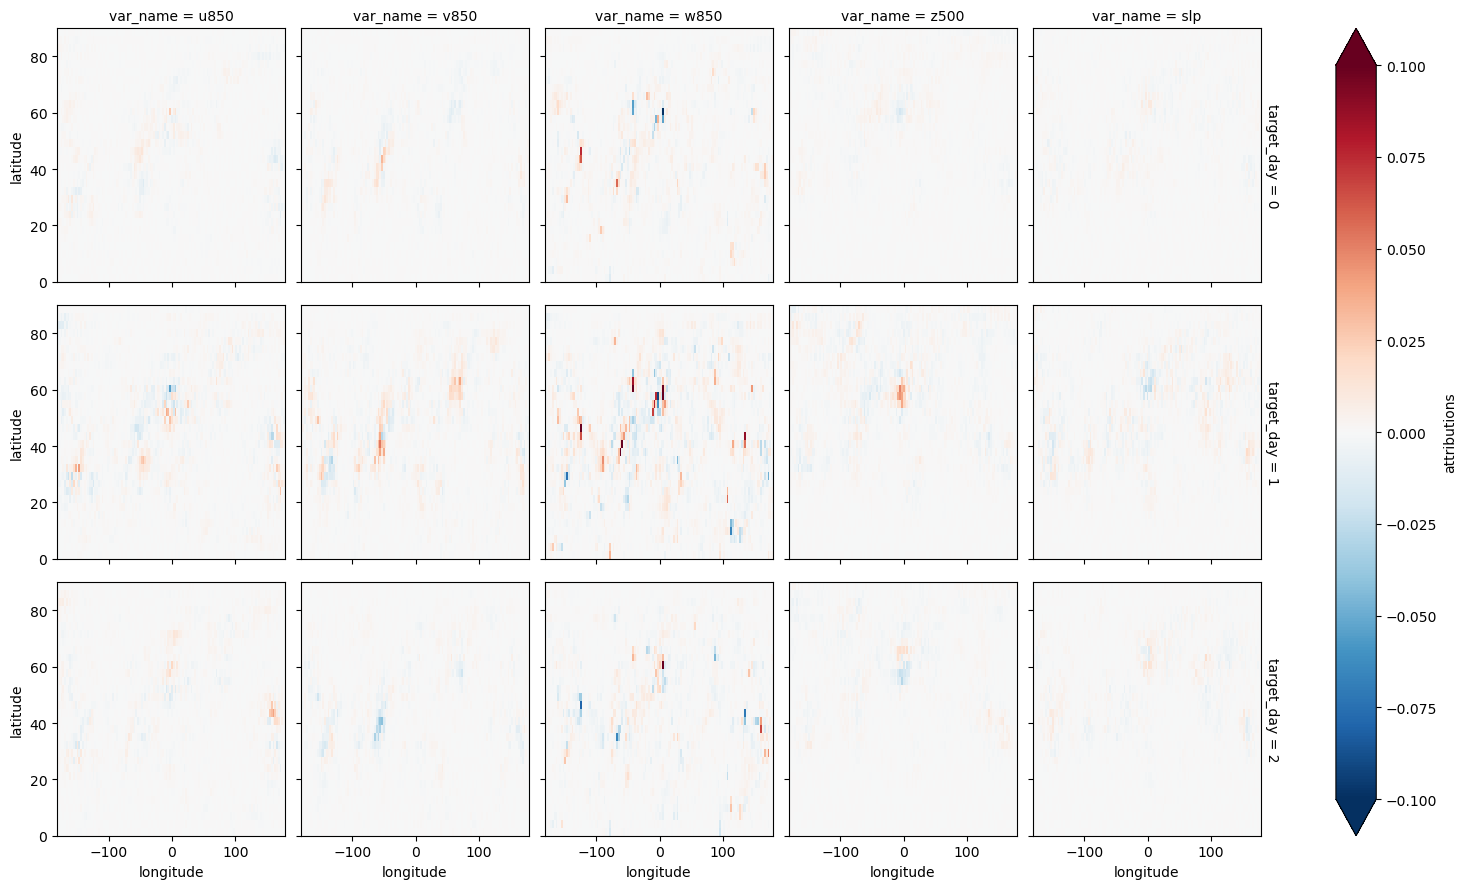

In [112]:
ds.isel(time=213).attributions.isel(lag=0).plot(col='var_name', row='target_day', vmax=.1)

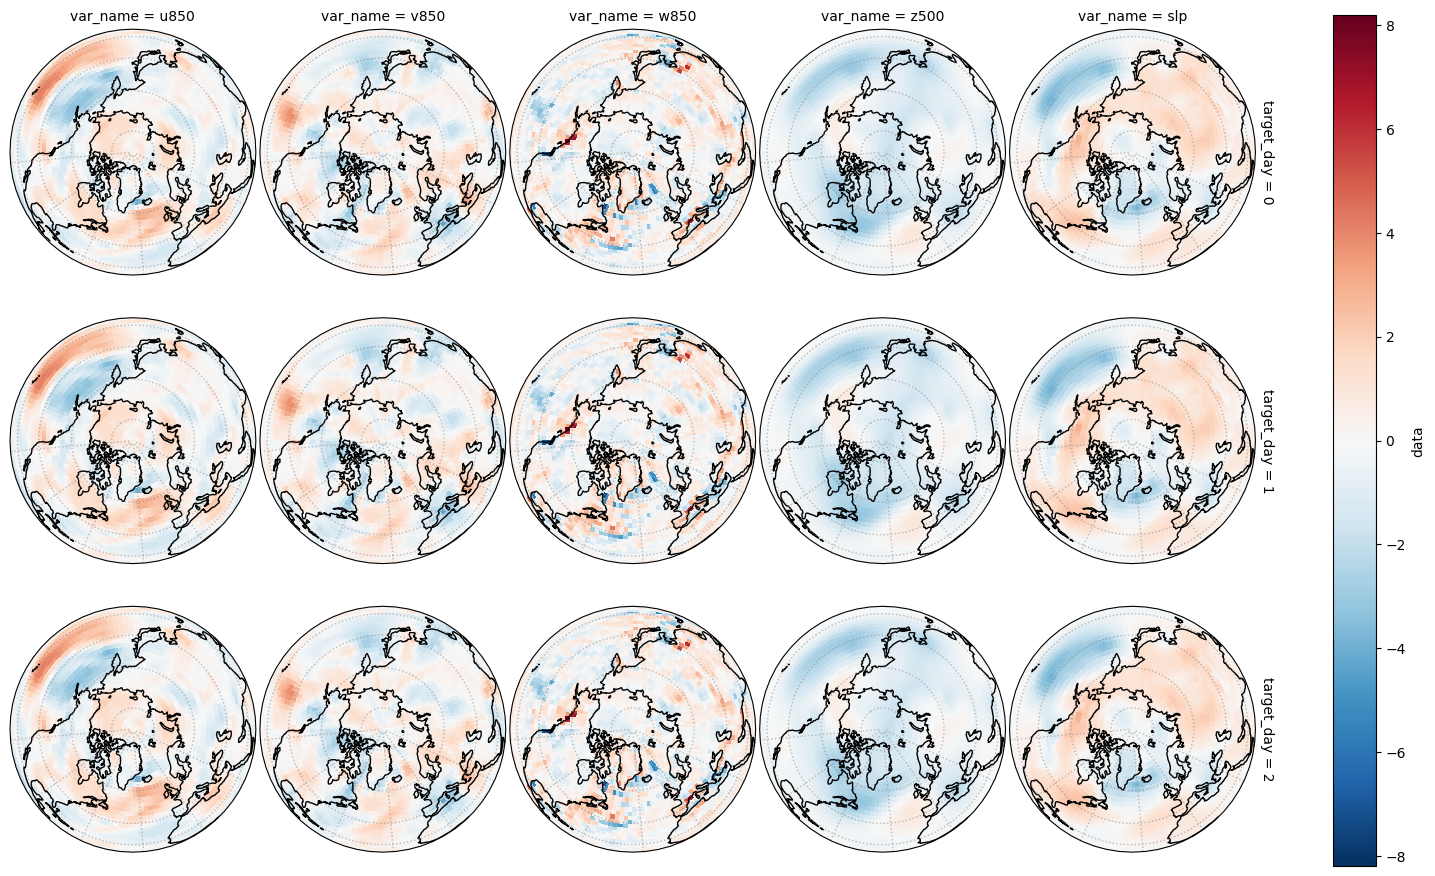

In [114]:
import matplotlib.path as mpath
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

plot = ds.isel(time=213).data.isel(lag=0).plot(row='target_day', col='var_name', 
                                                     subplot_kws = dict(projection=ccrs.Orthographic(-35,90)),
                                                     transform=ccrs.PlateCarree())
for k,ax in enumerate(plot.axs.flatten()):
    ax.coastlines()
    # if k<2:
    #     Q = lag_data.data.mean('time').coarsen(latitude=2, longitude=2).mean().to_dataset('var_name').plot.quiver(x='longitude', y='latitude', u='u850', v='v850', transform=ccrs.PlateCarree(), 
    #                                                                                                             alpha=0.3, ax=ax, scale=30, zorder=9,width=.004, pivot='mid', label=None,)
        # ax.quiverkey(Q, 0.9, 0.9, 2, r'$2 \frac{m}{s}$', labelpos='E',
        #            coordinates='figure')
    # ax.set_title(ds.var_name.isel(var_name=k%5).values)
    # ax.set_boundary(aoi, transform=ccrs.PlateCarree())
    # ax.set_extent((-120,45, 30,90), crs=ccrs.PlateCarree())
    make_gl(ax)

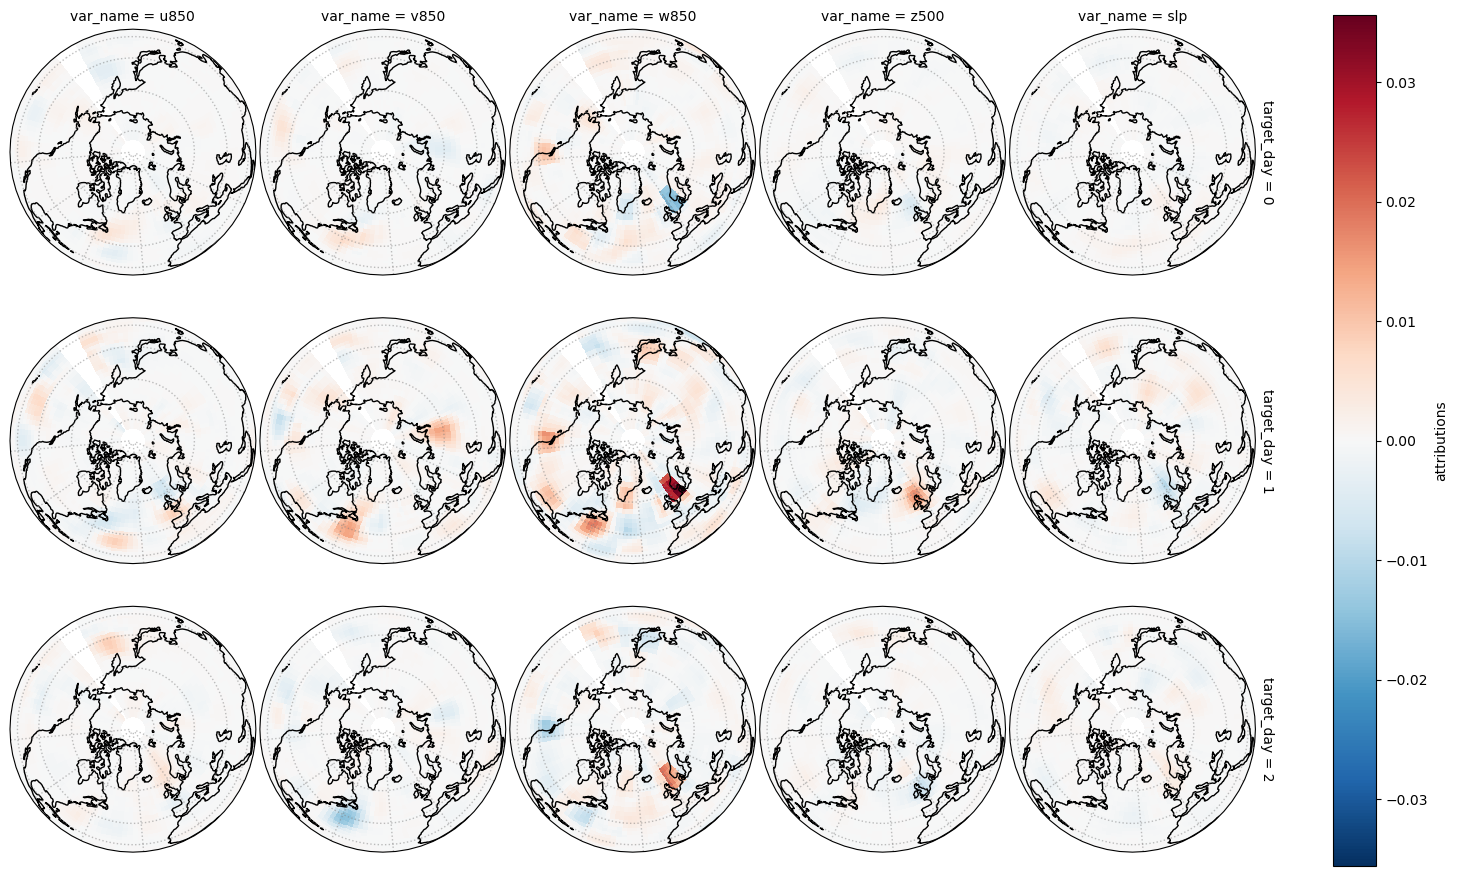

In [119]:
import matplotlib.path as mpath
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

plot = ds.isel(time=213).attributions.rolling(longitude=5, latitude=5, center=True).mean().isel(lag=0).plot(row='target_day', col='var_name', 
                                                     subplot_kws = dict(projection=ccrs.Orthographic(-35,90)),
                                                     transform=ccrs.PlateCarree())
for k,ax in enumerate(plot.axs.flatten()):
    ax.coastlines()
    # if k<2:
    #     Q = lag_data.data.mean('time').coarsen(latitude=2, longitude=2).mean().to_dataset('var_name').plot.quiver(x='longitude', y='latitude', u='u850', v='v850', transform=ccrs.PlateCarree(), 
    #                                                                                                             alpha=0.3, ax=ax, scale=30, zorder=9,width=.004, pivot='mid', label=None,)
        # ax.quiverkey(Q, 0.9, 0.9, 2, r'$2 \frac{m}{s}$', labelpos='E',
        #            coordinates='figure')
    # ax.set_title(ds.var_name.isel(var_name=k%5).values)
    # ax.set_boundary(aoi, transform=ccrs.PlateCarree())
    # ax.set_extent((-120,45, 30,90), crs=ccrs.PlateCarree())
    make_gl(ax)

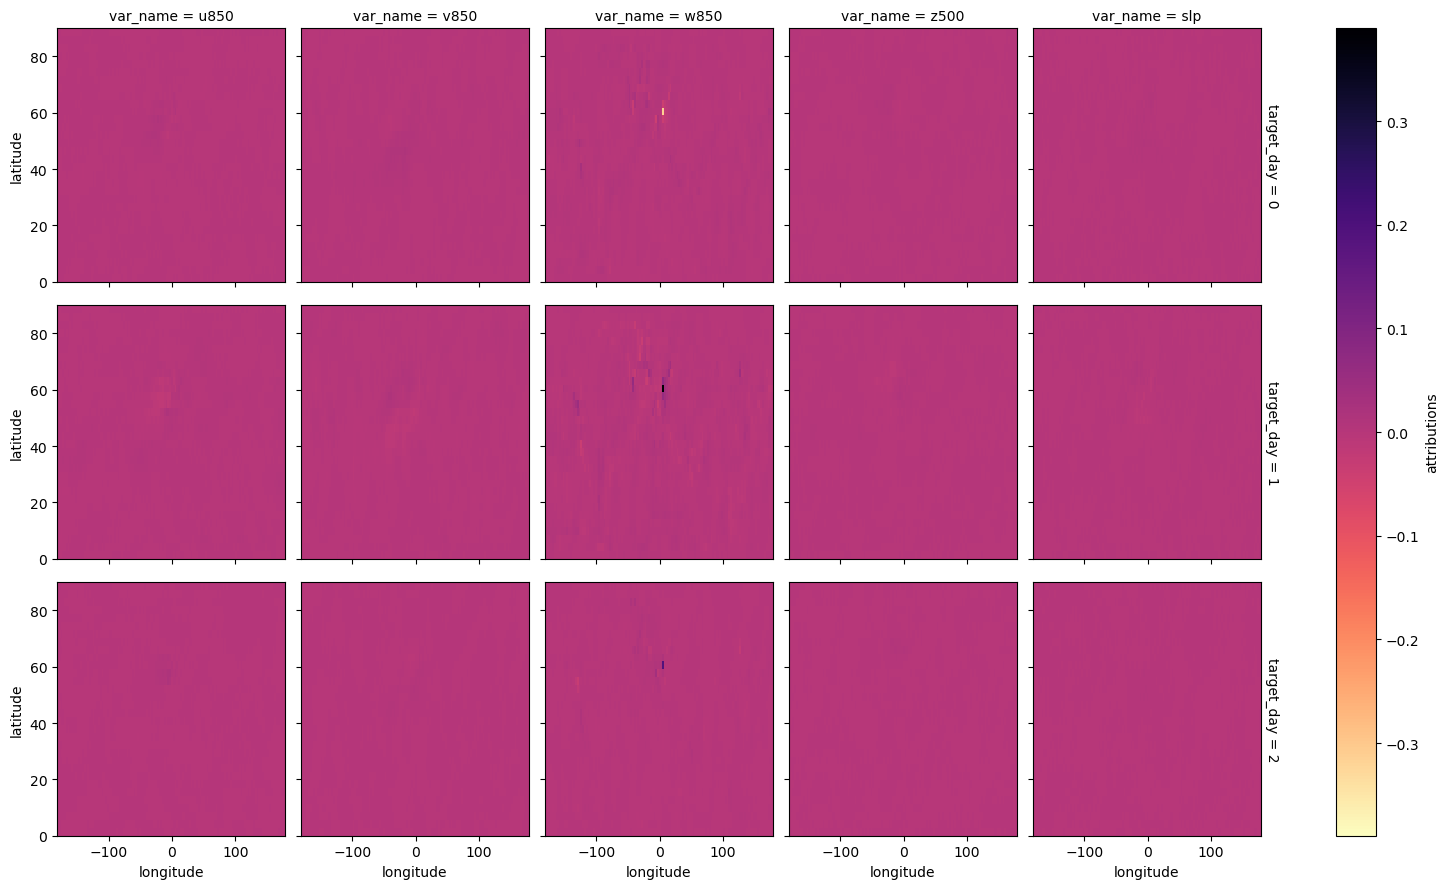

In [71]:
# S = ds.attributions.where(ds.attributions>0.1*ds.attributions.max(['longitude','latitude','var_name','lag']))
S = ds.attributions
S.mean('time').isel(lag=0).plot(col='var_name', row='target_day', cmap='magma_r')

In [ ]:
for target_day in range(1,wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.isel(time=true_indices).coords})
    pred_da = xr.DataArray(pred[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')

In [30]:
true_indices

array([  12,   12,   12,   14,   15,   28,   31,   31,   44,   50,   60,
         63,   68,   84,   84,  103,  108,  130,  130,  142,  167,  168,
        171,  173,  174,  178,  191,  196,  210,  213,  213,  216,  217,
        232,  250,  250,  254,  265,  269,  269,  288,  291,  305,  314,
        314,  323,  349,  352,  360,  360,  367,  387,  387,  399,  399,
        405,  425,  459,  462,  497,  517,  518,  551,  555,  557,  568,
        572,  572,  586,  586,  587,  612,  612,  612,  633,  638,  655,
        662,  666,  668,  672,  686,  696,  709,  710,  710,  713,  722,
        730,  732,  839,  846,  847,  855,  855,  867,  880,  884,  906,
        906,  926,  935,  936,  936,  940,  946,  946,  946,  952,  971,
        971,  984, 1013, 1013, 1013, 1027, 1028, 1028, 1030, 1031, 1031,
       1046, 1063, 1065, 1066, 1068, 1073, 1089, 1089, 1094, 1097, 1097,
       1110, 1111, 1116, 1122, 1125, 1131, 1141, 1143, 1152, 1199, 1225,
       1235, 1250, 1259, 1262, 1290, 1308, 1309, 13

In [26]:
pred_da = xr.DataArray(pred[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))
truth_da = xr.DataArray(truth[true_indices,target_day], dims=['time'], coords=dict(time=attribution_da.time))

ds_attr = xr.Dataset(dict(data = ds_test-ds_test.isel(time=true_indices).mean('time'),
                            attributions = attribution_da,
                            pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
all_attr.append(ds_attr.assign_coords(target_day=target_day))

ValueError: cannot reindex or align along dimension 'time' because the (pandas) index has duplicate values

In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.67346939 0.52473118 0.21827411]
Correlations: [0.86790533 0.78935618 0.59806459]


wandb: 
wandb: 🚀 View run floral-lake-43 at: https://wandb.ai/rguilcas-university-of-bergen/Predict-rain-WNorway_multidays/runs/h0ma45ix
wandb: Find logs at: ../../../../../../Data/gfi/users/rogui7909/wanbd_logs/wandb/run-20250318_142441-h0ma45ix/logs


<Axes: xlabel='truth_lag2', ylabel='pred_lag2'>

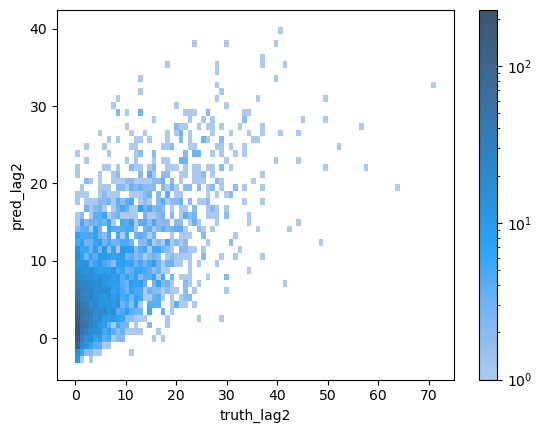

In [17]:
import seaborn as sns
from matplotlib.colors import LogNorm
sns.histplot(df,x='truth_lag2', y='pred_lag2', norm=LogNorm(), vmin=None, vmax=None, cbar=True)

In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.60235294 0.41551247 0.02272727]
Correlations: [0.86561869 0.78395378 0.59679169]


wandb: 
wandb: 🚀 View run unique-aardvark-33 at: https://wandb.ai/rguilcas-university-of-bergen/Predict-rain-WNorway_multidays/runs/99qq5tqv
wandb: Find logs at: ../../../../../../Data/gfi/users/rogui7909/wanbd_logs/wandb/run-20250318_122835-99qq5tqv/logs


In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.65952891 0.44730077 0.03717472]
Correlations: [0.85768829 0.78254106 0.60076339]


In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.65050505 0.50530786 0.28061224]
Correlations: [0.84522379 0.76710051 0.57634564]


<Axes: xlabel='truth_lag2', ylabel='pred_lag2'>

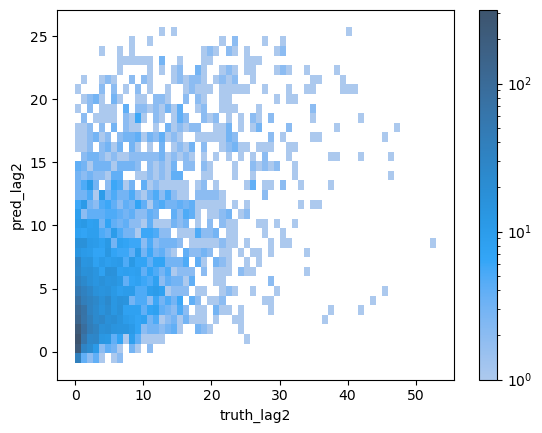

In [26]:
import seaborn as sns
from matplotlib.colors import LogNorm
sns.histplot(df,x='truth_lag2', y='pred_lag2', norm=LogNorm(), vmin=None, vmax=None, cbar=True)

In [8]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

F1 scores: [0.67748479 0.50638298 0.21752266]
Correlations: [0.85796012 0.77486675 0.58399247]


In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

recall = ((truth>20)&(pred>20)).sum(axis=0)/((truth>20)).sum(axis=0)
precision = ((truth>20)&(pred>20)).sum(axis=0)/((pred>20)).sum(axis=0)
f1 = recall*precision*2/(precision+recall)
print("F1 scores:",f1)
print("Correlations:",np.diag(df.corr().iloc[:df.columns.size//2,df.columns.size//2:]))

In [ ]:
min_rain = 21
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
true_indices = np.where((truth[:,2]>=min_rain)&(pred[:,2]>=min_rain))[0]
data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
data_out_true_target = torch.Tensor(pred[true_indices])
dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
attribution_loader = DataLoader(dataset_attr, batch_size=10)

baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(model.model)
# dl = DeepLift(model.model)

attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=2, attribution_method=ig)
# attribution_nt = self.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
# attribution_dl = self.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

attribution_da = xr.DataArray([attribution_ig], 
                            dims=['attr_method']+list(ds_test.dims), 
                            coords={'attr_method':['IntegratedGradients', 
                                                #    'IntegratedGradients+NoiseTunnel'
                                                    ], 
                                    **ds_test.isel(time=true_indices).coords})
pred_da = xr.DataArray(pred[true_indices,2], dims=['time'], coords=dict(time=attribution_da.time))
truth_da = xr.DataArray(truth[true_indices,2], dims=['time'], coords=dict(time=attribution_da.time))

ds_attr = xr.Dataset(dict(data = ds_test.isel(time=true_indices)-ds_test.mean('time'),
                            attributions = attribution_da,
                            pred=pred_da, truth = truth_da)).sortby('time').assign_coords(min_rain=min_rain)
ds_attr.attrs['baseline_prediction'] = model(baseline).detach().numpy().squeeze()

In [ ]:
ds_attr.mean('time').attributions.plot(col='lag',row='var_name')

In [ ]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

In [ ]:
df.corr()

In [ ]:
min_rain = 0
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()

# true_indices = np.where((truth>=min_rain)&(pred>=min_rain))[0]
# data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
# data_out_true_target = torch.Tensor(pred[true_indices])
# dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
# attribution_loader = DataLoader(dataset_attr, batch_size=10)
attribution_loader = test_loader
baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(trainer.model.model)
# dl = DeepLift(trainer.model.model)
all_attr = []
for target_day in range(wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.coords})
    pred_da = xr.DataArray(pred[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')
# ds_attr.attrs['baseline_prediction'] = trainer.model(baseline).detach().numpy().squeeze()

In [ ]:
ds_over20 = ds.where((ds.pred>20)&(ds.truth>20), drop=True)

In [ ]:
ds_over20.mean('time').attributions.plot(col='lag', row='var_name')

In [ ]:

    viT = VisionTransformerRegressor(
                num_classes=num_output_neurons, 
                num_channels_in=ds_test.features.size, 
                patch_size = patch_size=16
                image_size=image_size, 
                groups=len(len(wandb_logger.experiment.config['input_variable']),
                size_conv1_kernel=wandb_logger.experiment.config['conv1_kernel_size'],
                size_conv2_kernel=wandb_logger.experiment.config['conv2_kernel_size'],
                out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'],
                out_channels_conv2=wandb_logger.experiment.config['conv2_kernel_number'],
                dropout_proba=wandb_logger.experiment.config['dropout_proba'],)


    loss = get_loss(wandb_logger.experiment.config['loss_fn'])


    model = LitCNN_regression(CNN, 
                            learning_rate=wandb_logger.experiment.config['learning_rate'], 
                            loss_fn = loss)

    print('Model init')
    trainer.fit(model, train_loader, valid_loader)


    model.eval()
    with torch.no_grad():
        trainer.test(model, dataloaders=test_loader)

In [ ]:
truth